# Data Cleaning Notebook

## Goals
The goal of this section is to ensure the dataset is clean, consistent, and ready for feature engineering and modeling. Data cleaning is a crucial step in the data science workflow, as the quality of the data directly impacts the quality of the insights and predictions generated by the model.

## Objectives
- Identify and handle missing values appropriately.
- Remove or address redundant variables if necessary.
- Prepare the dataset for feature engineering and modeling tasks.

## Inputs
- The `house_prices_records_encoded.csv` dataset containing property information and sale prices.
- Initial insights gathered from the exploratory data analysis (EDA) phase.

## Outputs
- A cleaned version of the dataset with missing data treated.
- A list of columns removed or transformed during cleaning.
- A ready-to-use dataset for the next stage: feature engineering.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5\\heritage-housing-ml-pgz\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5\\heritage-housing-ml-pgz'

# Handling Missing Data

## Load the data

In [4]:
import pandas as pd
df_raw_encoded_path = "outputs/datasets/collection/house_prices_records_encoded.csv"
df_encoded_duplicates = pd.read_csv(df_raw_encoded_path)
df_encoded_duplicates.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice,KitchenQual_Enc,GarageFinish_Enc,BsmtExposure_Enc,BsmtFinType1_Enc
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,7,856,0.0,2003,2003,208500,3,1.0,0.0,4.0
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,6,1262,NaN,1976,1976,181500,2,1.0,3.0,3.0
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,7,920,NaN,2001,2002,223500,3,1.0,1.0,4.0


### Removing Duplicate Columns

As we applied ordinal encoding to the categorical columns in the previous section, we will now remove the duplicate entries from our dataset to proceed with the analysis of missing data. Specifically, we will drop the original categorical columns and retain only their encoded versions, as these were already used in our correlation analysis.


In [6]:
# Remove original  categorical columns that have corresponding encoded versions
columns_to_drop = ['GarageFinish', 'BsmtExposure', 'BsmtFinType1','KitchenQual']
df =df_encoded_duplicates.drop(columns=columns_to_drop)

# Save cleaned dataset to new file
output_path = "outputs/datasets/collection/house_prices_records_encoded_no_duplicates.csv"
df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved as: {output_path}")


Cleaned dataset saved as: outputs/datasets/collection/house_prices_records_encoded_no_duplicates.csv


## Analyzing missing data

From the previous Data Analysis section, we identified several variables with missing values. The results of the data profiling identified the following variables as the ones with the highest percentage of missing data:

- Features with the highest percentage of missing data:
  - `WoodDeckSF`: 89.4%
  - `EnclosedPorch`: 90.7%
  - `GarageFinish`: 16.1%
  - `LotFrontage`: 17.7%
  - `BsmtFinType1`: 9.9%
  - `BedroomAbvGr`: 6.8%

We will now proceed with a detailed analysis of the missing data. As a first step, we will profile the variables with missing values to better understand their structure, distribution, and contextual relevance. This will guide our decision-making process for handling missing data appropriately.

As a first step, we will gather all variables that contain at least one missing value. We will then proceed with a profiling of these variables.

In [7]:
def EvaluateMissingData(df):
    vars_missing_data = df.columns[df.isna().sum() > 0].to_list()
    return vars_missing_data

EvaluateMissingData(df)

['2ndFlrSF',
 'BedroomAbvGr',
 'EnclosedPorch',
 'GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'WoodDeckSF',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

In [8]:
from ydata_profiling import ProfileReport

vars_missing_data = EvaluateMissingData(df)

if vars_missing_data:
    profile = ProfileReport(df=df[vars_missing_data], minimal=True)
    profile.to_file("outputs/reports/missing_data_profile.html")
    print("Profile saved to output/missing_data_profile.html")
else:
    print("There are no variables with missing data")


c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 200.20it/s]

Profile saved to output/missing_data_profile.html


Already from the initial results, we observe that both `WoodDeckSF` and `EnclosedPorch` have more than 89% of their data missing. Given the extent of the missingness and the assumption that their contribution to the sale price estimation is likely minimal, it is reasonable to consider excluding these variables from further analysis. For the rest of the variables are more detailed anylsis is required. 

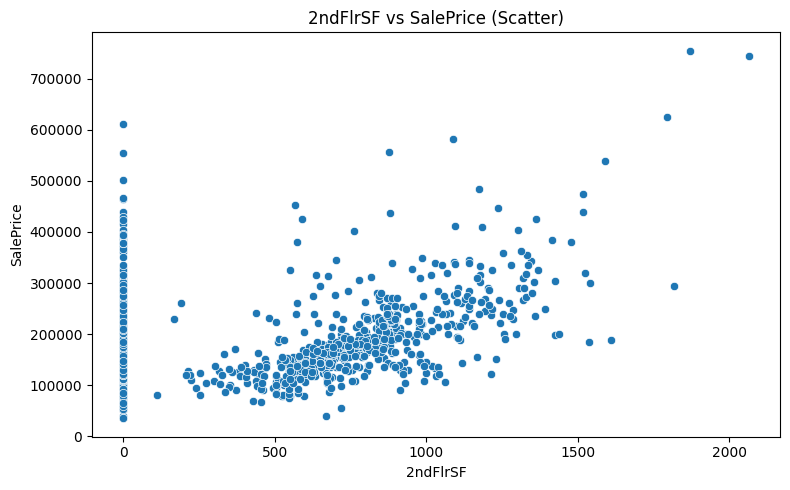

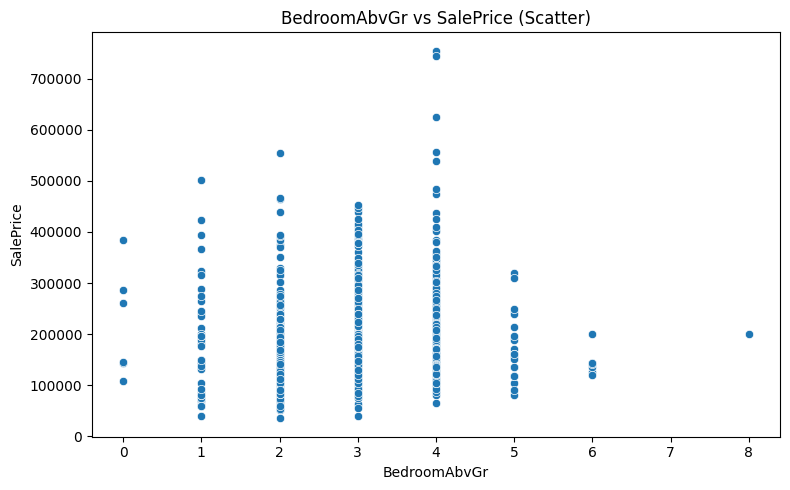

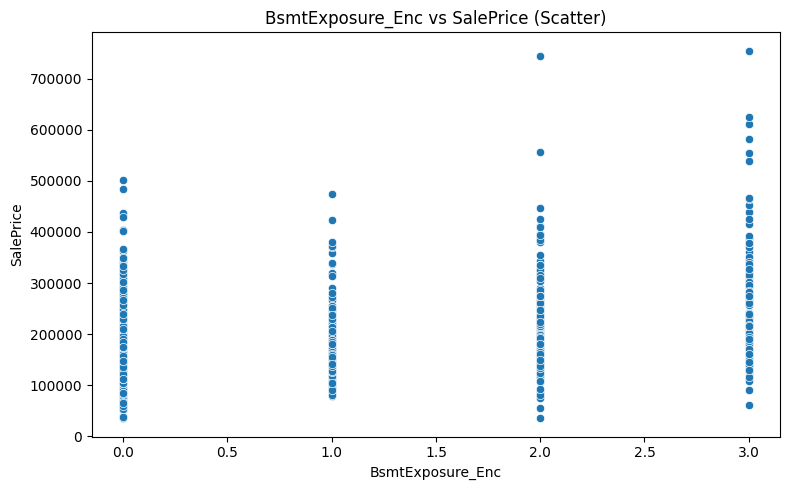

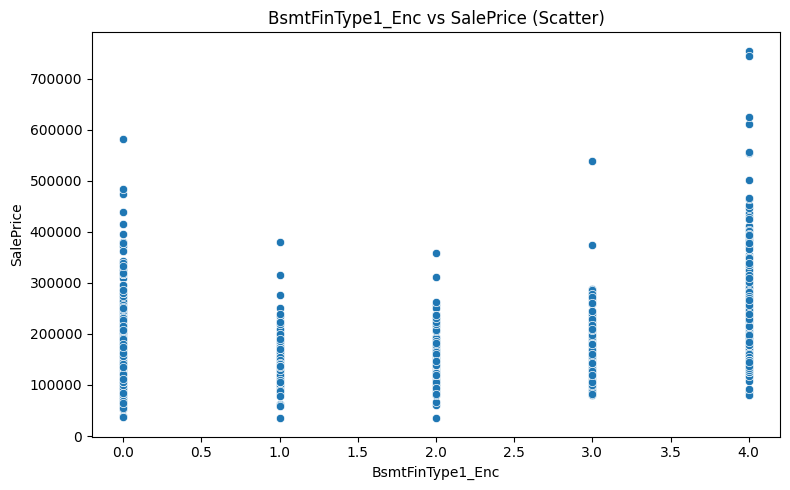

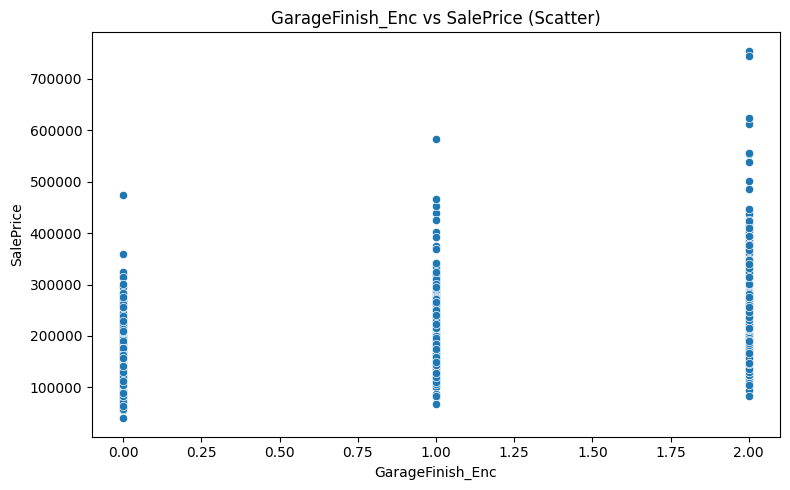

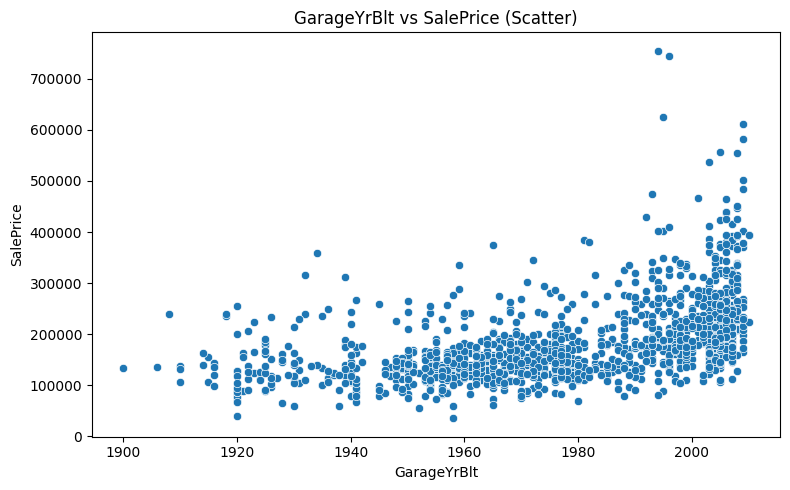

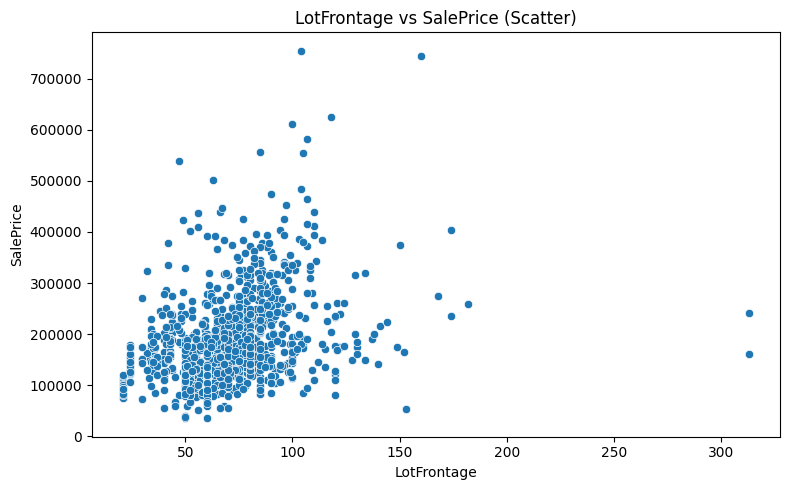

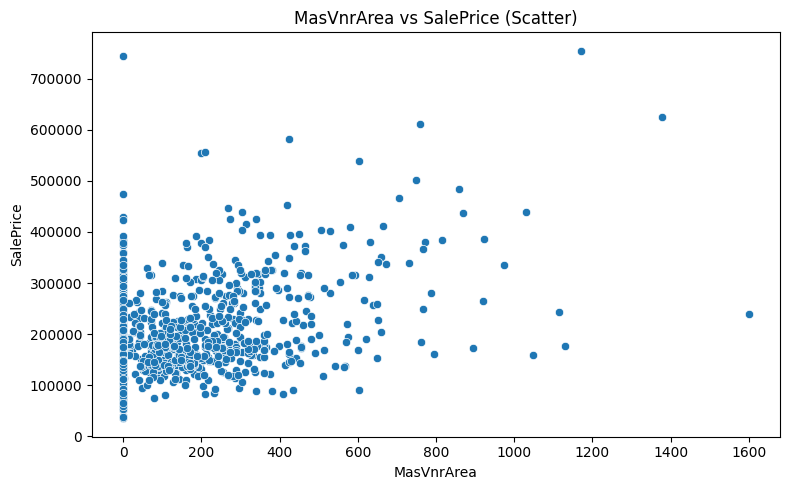

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


# Variables excluding `WoodDeckSF` and `EnclosedPorch`
all_missing_vars = [
    '2ndFlrSF', 'BedroomAbvGr', 'BsmtExposure_Enc', 'BsmtFinType1_Enc',
    'GarageFinish_Enc', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea'
]

# Filter variables that still exist in the current dataframe
vars_to_plot = [var for var in all_missing_vars if var in df.columns]

# Plot each variable against SalePrice
for var in vars_to_plot:
    plt.figure(figsize=(8, 5))
    
    if df[var].dtype in ['int64', 'float64']:
        sns.scatterplot(data=df, x=var, y='SalePrice')
        plt.title(f'{var} vs SalePrice (Scatter)')
    else:
        sns.boxplot(data=df, x=var, y='SalePrice')
        plt.title(f'{var} vs SalePrice (Boxplot)')
    
    plt.tight_layout()
    plt.show()


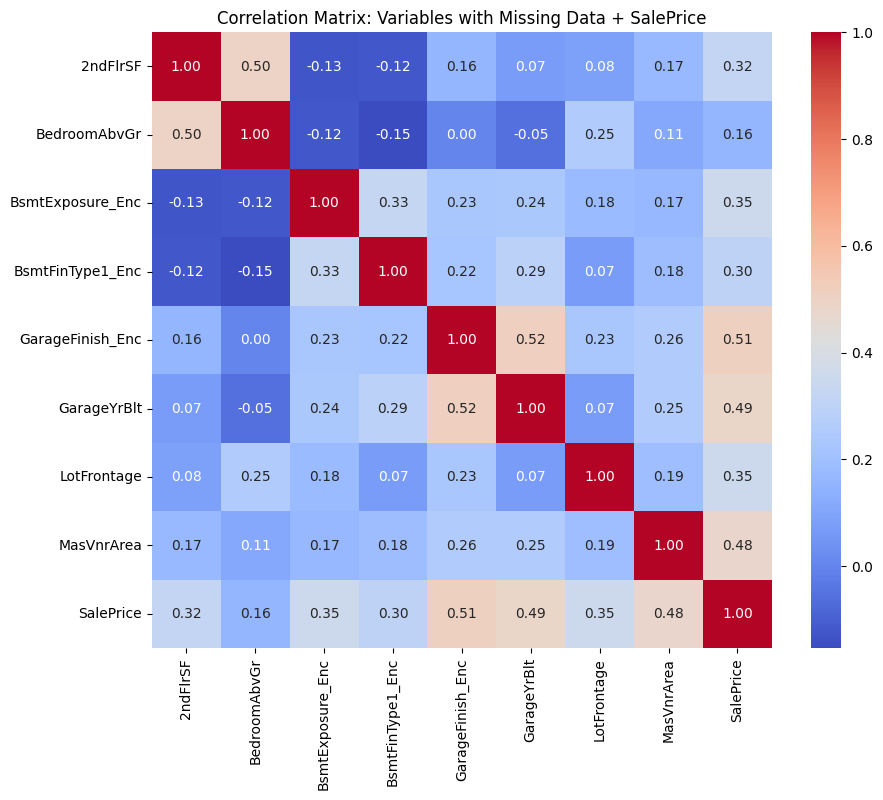

In [10]:
# Plotting correlation heatmap for variables with missing data + SalePrice
plt.figure(figsize=(10, 8))
sns.heatmap(df[vars_to_plot + ['SalePrice']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Variables with Missing Data + SalePrice")
plt.show()


## Data Imputation

We have identified the variables with missing data and examined their correlations with other features as well as with the target variable, `SalePrice`. 

Before applying imputation strategies, we will first split the dataset into a training set and a test set. Once the split is complete, we will go through each variable with missing values to determine the most appropriate imputation approach.

Once the data is split into the corresponding train and test sets we will perform the imputation as follows:

1. Select a specific imputation strategy based on percentage of missing data, correlation, type
2. Apply the imputation strategy on a temporary test set
3. Review the distribution result after the imputation. To visualize the effects we will compare the distribution of the set before and after the imputation using the function `compare_distributions`
4. Apply the changes to the set
5. Review if there are still missing values on the set using the function `EvaluateMissingData`



In [11]:
import matplotlib.pyplot as plt


def compare_distributions(original_series, imputed_series, variable_name, bins=None):
    
    plt.figure(figsize=(10, 5))
    original_series.hist(alpha=0.6, bins=bins, label='Before Imputation')
    imputed_series.hist(alpha=0.6, bins=bins, label='After Imputation')

    plt.title(f'Distribution of {variable_name}: Before vs After Imputation')
    plt.xlabel(variable_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#### Split Data

In [12]:
from sklearn.model_selection import train_test_split
TrainSet, TestSet, _, __ = train_test_split(
                                        df,
                                        df['SalePrice'],
                                        test_size=0.2,
                                        random_state=0)

print(f"TrainSet shape: {TrainSet.shape} \nTestSet shape: {TestSet.shape}")

TrainSet shape: (1168, 24) 
TestSet shape: (292, 24)


In [13]:
df_missing_data = EvaluateMissingData(TrainSet)
print(f"* There are {df_missing_data} variables with missing data \n")
df_missing_data

* There are ['2ndFlrSF', 'BedroomAbvGr', 'EnclosedPorch', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea', 'WoodDeckSF', 'GarageFinish_Enc', 'BsmtExposure_Enc', 'BsmtFinType1_Enc'] variables with missing data 



['2ndFlrSF',
 'BedroomAbvGr',
 'EnclosedPorch',
 'GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'WoodDeckSF',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

#### Imputation  `WoodDeckSF` and `EnclosedPorch`

As mentioned before, these two features should be dropped as they have more than 80% of their data missing. 

In [14]:
features_to_drop = ['WoodDeckSF', 'EnclosedPorch' ]

from feature_engine.selection import DropFeatures
imputer = DropFeatures(features_to_drop)
imputer.fit(TrainSet)
df_method = imputer.transform(TrainSet)
EvaluateMissingData(df_method)

['2ndFlrSF',
 'BedroomAbvGr',
 'GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

Considering that we are dropping colums, we don't need to make any further analysis of these 2 features and we can apply the changes directly into our Test and Train Sets. 


In [15]:
from feature_engine.selection import DropFeatures
imputer = DropFeatures(features_to_drop)
imputer.fit(TrainSet)

TrainSet, TestSet = imputer.transform(TrainSet) , imputer.transform(TestSet)
EvaluateMissingData(TrainSet)

['2ndFlrSF',
 'BedroomAbvGr',
 'GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

#### Imputation:  `2ndFlrSF` 

- This is a numerical variable representing the square footage of the second floor.
- It has around 5.9% missing data.
- It shows a moderate correlation with `SalePrice`.
- Since the values are continuous and the missingness is relatively low, we will impute the missing values using the **median** of the column.
- Median is chosen over mean to reduce the impact of potential outliers.

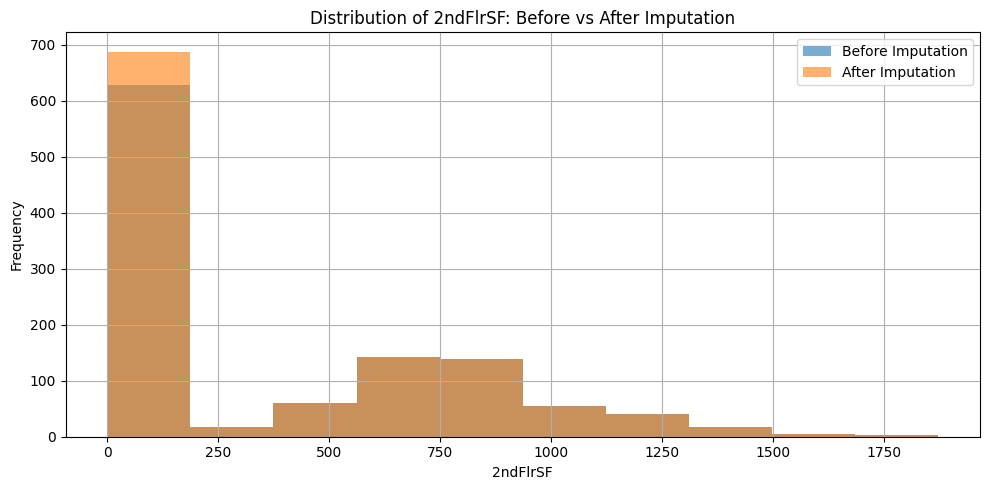

In [16]:
# Step 1: Create temporary copy for testing
TrainSet_temp = TrainSet.copy()

# Step 2: Compute median from original TrainSet
median_2ndFlrSF = TrainSet['2ndFlrSF'].median()

# Step 3: Apply imputation to the copy
TrainSet_temp['2ndFlrSF'] = TrainSet_temp['2ndFlrSF'].fillna(median_2ndFlrSF)

# Step 4: Compare distribution
compare_distributions(
    original_series=TrainSet['2ndFlrSF'],
    imputed_series=TrainSet_temp['2ndFlrSF'],
    variable_name='2ndFlrSF'
)

#### Apply Imputation: 2ndFlrSF

- The distribution comparison shows no significant distortion.
- We now apply the imputation to both `TrainSet` and `TestSet` using the median value calculated from the `TrainSet`.


In [17]:
# Apply final imputation using TrainSet median

TrainSet['2ndFlrSF'] = TrainSet['2ndFlrSF'].fillna(median_2ndFlrSF)
TestSet['2ndFlrSF'] = TestSet['2ndFlrSF'].fillna(median_2ndFlrSF)

# Check for missing data
EvaluateMissingData(TrainSet)

['BedroomAbvGr',
 'GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

### Imputation: BedroomAbvGr

- This is a numerical variable representing the number of bedrooms above ground level.
- It contains about 6.8% missing values.
- It has low correlation with `SalePrice`, but it can provide useful information about the size of a house.
- Since it’s discrete and ordinal, we will impute the missing values using the **mode** (most frequent value) from the `TrainSet`.
- Before applying, we will test the imputation on a temporary copy of the dataset and compare the distributions.


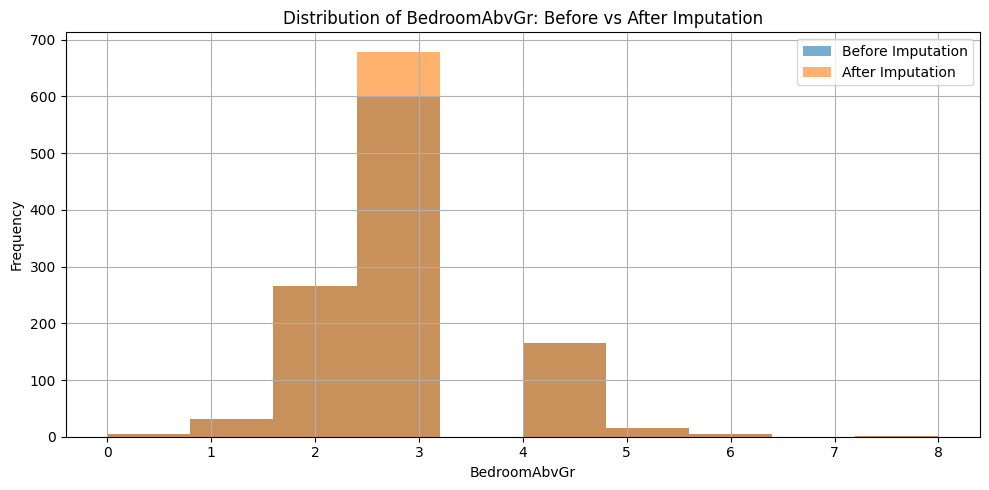

In [18]:
# Step 1: Create temporary copy for testing
TrainSet_temp = TrainSet.copy()

# Step 2: Compute mode from TrainSet
mode_bedrooms = TrainSet['BedroomAbvGr'].mode().iloc[0]

# Step 3: Apply imputation to the copy
TrainSet_temp['BedroomAbvGr'] = TrainSet_temp['BedroomAbvGr'].fillna(mode_bedrooms)

# Step 4: Compare distribution
compare_distributions(
    original_series=TrainSet['BedroomAbvGr'],
    imputed_series=TrainSet_temp['BedroomAbvGr'],
    variable_name='BedroomAbvGr'
)


##### Apply Imputation: BedroomAbvGr

- The distribution comparison shows no significant distortion.
- We now apply the imputation to both `TrainSet` and `TestSet` using the mode value calculated from the `TrainSet`.

In [19]:
# Apply final imputation using TrainSet mode
TrainSet['BedroomAbvGr'] = TrainSet['BedroomAbvGr'].fillna(mode_bedrooms)
TestSet['BedroomAbvGr'] = TestSet['BedroomAbvGr'].fillna(mode_bedrooms)

# Check for missing data
EvaluateMissingData(TrainSet)

['GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

#### Imputation: GarageYrBlt

- This variable represents the year the garage was built.
- It has about 5.5% missing values and a strong correlation with `SalePrice`.
- Based on the encoding of `GarageFinish_Enc`, we can assume:
  - Values `0`, `1`, or `2` indicate that a garage exists.
  - Missing (`NaN`) values indicate that no garage is present.
- Imputation logic:
  - If a garage exists (`GarageFinish_Enc` is not null), we fill missing `GarageYrBlt` with the value of `YearBuilt`.
  - If no garage exists (`GarageFinish_Enc` is null), we fill `GarageYrBlt` with `0`.
- We will apply this logic to a copy first and compare the distribution.



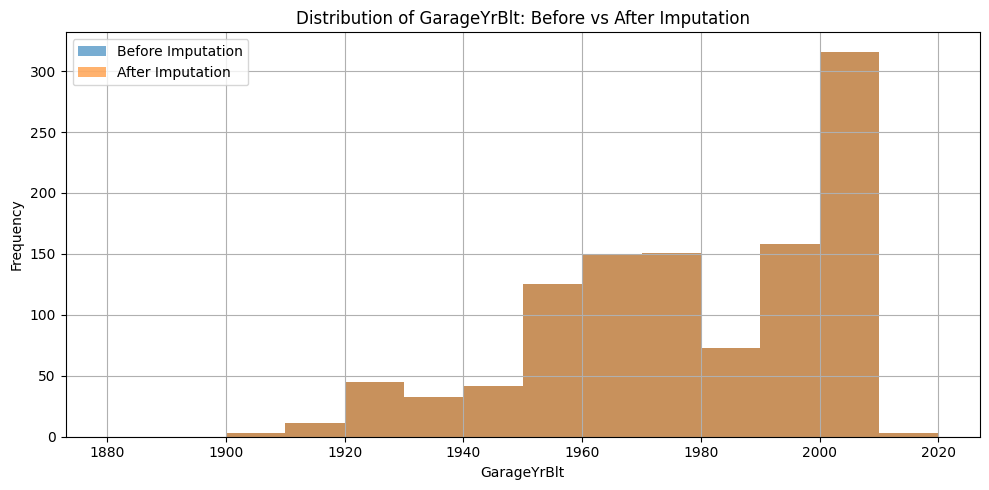

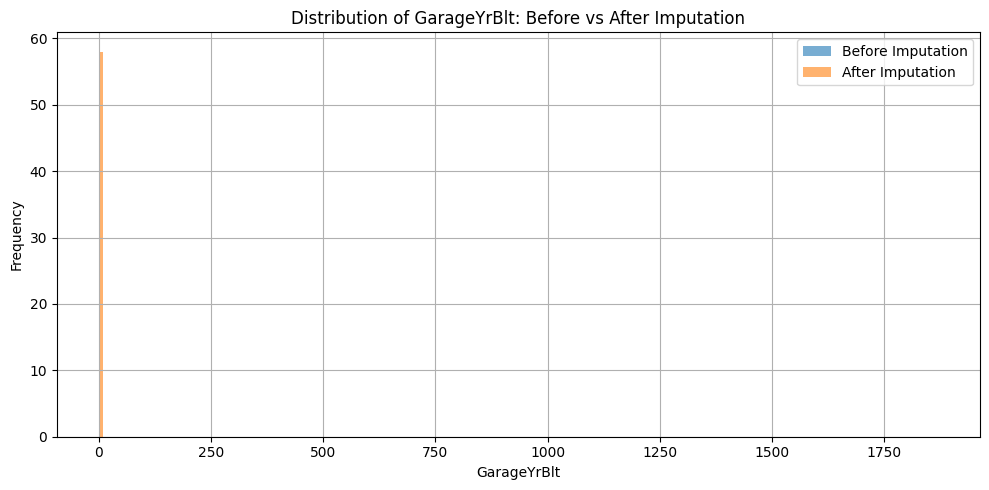

In [21]:
# Create a temporary copy for testing
TrainSet_temp = TrainSet.copy()

# Define garage existence: GarageFinish_Enc not null means garage exists
garage_exists = TrainSet['GarageFinish_Enc'].notna()

# Apply conditional imputation on the copy
TrainSet_temp['GarageYrBlt'] = TrainSet['GarageYrBlt'].copy()
TrainSet_temp.loc[garage_exists & TrainSet_temp['GarageYrBlt'].isna(), 'GarageYrBlt'] = TrainSet_temp['YearBuilt']
TrainSet_temp.loc[~garage_exists & TrainSet_temp['GarageYrBlt'].isna(), 'GarageYrBlt'] = 0



# Compare distributions starting from 1880
year_bins_1880 = list(range(1880, 2025, 10))

compare_distributions(
    
    original_series=TrainSet['GarageYrBlt'],
    imputed_series=TrainSet_temp['GarageYrBlt'],
    variable_name='GarageYrBlt',
    bins=year_bins_1880
)

# Compare distributions starting from year 0
year_bins_0= list(range(0, 1880, 10))

compare_distributions(
    
    original_series=TrainSet['GarageYrBlt'],
    imputed_series=TrainSet_temp['GarageYrBlt'],
    variable_name='GarageYrBlt',
    bins=year_bins_0
)


##### Apply Imputation: GarageYrBlt

- The updated histogram confirms that the imputation does not significantly distort the distribution.
- We will now apply the final logic:
  - If a garage exists (`GarageFinish_Enc` is not null), impute `GarageYrBlt` using `YearBuilt`.
  - If no garage exists (`GarageFinish_Enc` is null), impute with 0.
- This will be done consistently for both `TrainSet` and `TestSet`.


In [22]:
# Apply to TrainSet
garage_exists_train = TrainSet['GarageFinish_Enc'].notna()
TrainSet.loc[garage_exists_train & TrainSet['GarageYrBlt'].isna(), 'GarageYrBlt'] = TrainSet.loc[garage_exists_train, 'YearBuilt']
TrainSet.loc[~garage_exists_train & TrainSet['GarageYrBlt'].isna(), 'GarageYrBlt'] = 0

# Apply to TestSet
garage_exists_test = TestSet['GarageFinish_Enc'].notna()
TestSet.loc[garage_exists_test & TestSet['GarageYrBlt'].isna(), 'GarageYrBlt'] = TestSet.loc[garage_exists_test, 'YearBuilt']
TestSet.loc[~garage_exists_test & TestSet['GarageYrBlt'].isna(), 'GarageYrBlt'] = 0

EvaluateMissingData(TrainSet)

['LotFrontage',
 'MasVnrArea',
 'GarageFinish_Enc',
 'BsmtExposure_Enc',
 'BsmtFinType1_Enc']

### Imputation: LotFrontage

- This variable represents the linear feet of street connected to the property.
- It has around 17.7% missing values.
- It shows moderate correlation with `SalePrice`.
- We will use the **overall median** from the `TrainSet` to impute missing values.
- We will apply this imputation to a copy of the data first and compare the distribution.


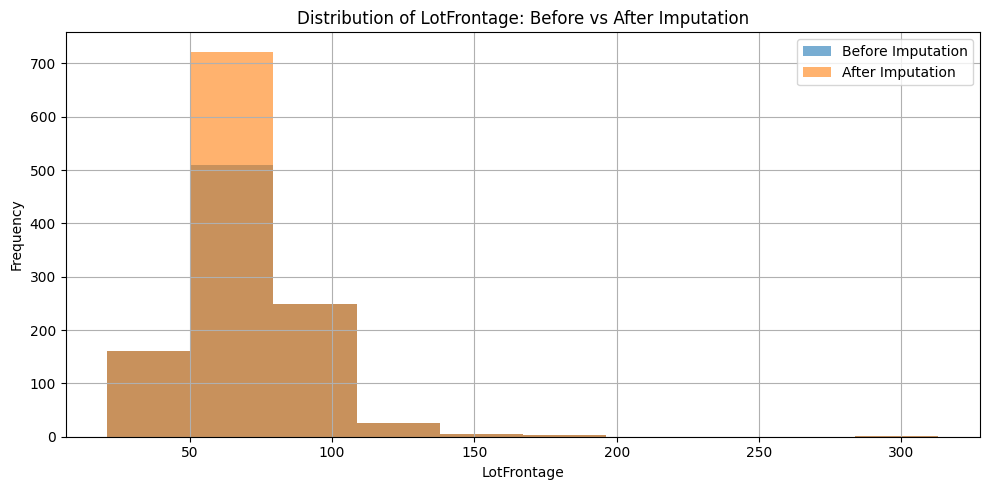

In [23]:
# Step 1: Create a temporary copy of TrainSet
TrainSet_temp = TrainSet.copy()

# Step 2: Compute median from TrainSet
median_lotfrontage = TrainSet['LotFrontage'].median()

# Step 3: Apply imputation to the copy
TrainSet_temp['LotFrontage'] = TrainSet_temp['LotFrontage'].fillna(median_lotfrontage)

# Step 4: Compare distributions
compare_distributions(
    original_series=TrainSet['LotFrontage'],
    imputed_series=TrainSet_temp['LotFrontage'],
    variable_name='LotFrontage'
)


#### Apply Imputation: LotFrontage

- The distribution comparison confirms that the imputation does not significantly affect the shape of the data.
- We now apply the imputation using the median value from `TrainSet` to both `TrainSet` and `TestSet`.


In [24]:
# Apply final imputation
TrainSet['LotFrontage'] = TrainSet['LotFrontage'].fillna(median_lotfrontage)
TestSet['LotFrontage'] = TestSet['LotFrontage'].fillna(median_lotfrontage)

# Check for missing data
EvaluateMissingData(TrainSet)

['MasVnrArea', 'GarageFinish_Enc', 'BsmtExposure_Enc', 'BsmtFinType1_Enc']

### Imputation: MasVnrArea

- This variable represents the masonry veneer area (in square feet) of the house exterior.
- It contains missing values, which may indicate either missing records or the absence of veneer on some houses.
- The correlation with `SalePrice` presents a moderately important relantionship with the target feature.
- A missing value often corresponds to **no veneer**, which logically equates to **0 square feet**.
- Therefore, we will impute missing values using `0`, as this best reflects the actual meaning.


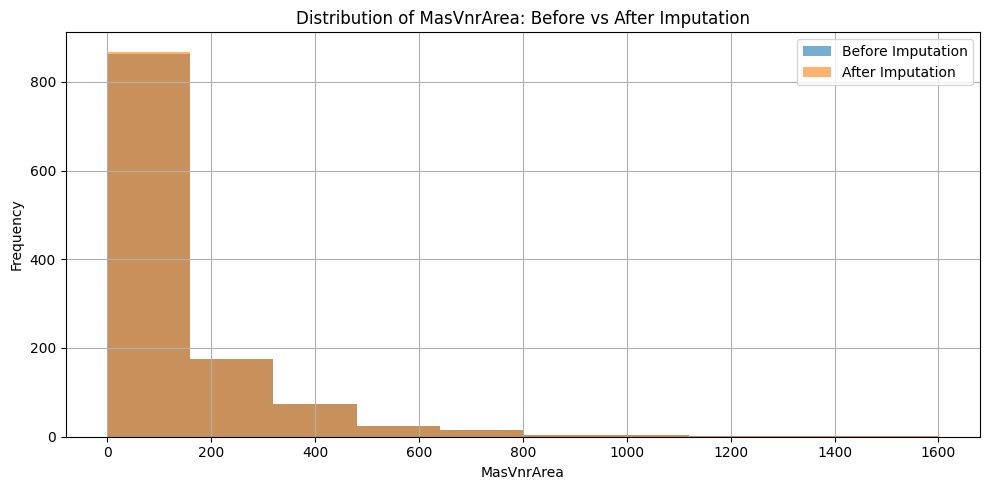

In [25]:
# Step 1: Create a temporary copy of TrainSet
TrainSet_temp = TrainSet.copy()

# Step 2: Apply imputation using 0 (assume missing means no veneer)
TrainSet_temp['MasVnrArea'] = TrainSet_temp['MasVnrArea'].fillna(0)

# Step 3: Compare distributions
compare_distributions(
    original_series=TrainSet['MasVnrArea'],
    imputed_series=TrainSet_temp['MasVnrArea'],
    variable_name='MasVnrArea'
)


#### Apply Imputation: MasVnrArea

- The distribution comparison confirmed that the imputation using 0 does not distort the data.
- We now apply the imputation to both `TrainSet` and `TestSet`, replacing missing values with 0 to indicate no veneer.


In [26]:
# Apply final imputation for MasVnrArea using 0
TrainSet['MasVnrArea'] = TrainSet['MasVnrArea'].fillna(0)
TestSet['MasVnrArea'] = TestSet['MasVnrArea'].fillna(0)

# Check for missing data
EvaluateMissingData(TrainSet)

['GarageFinish_Enc', 'BsmtExposure_Enc', 'BsmtFinType1_Enc']

### Imputation: GarageFinish_Enc

- This variable is the ordinal-encoded version of the garage finish type:
  - Unfinished: 0
  - Rough Finished: 1
  - Finished: 2
- It shows a moderate to strong correlation with `SalePrice`
- Missing values do not indicate whether a garage exists.
- They simply mean that no information is available about the garage finish. 
- To preserve the feature and its predictive potential:
  - We will impute missing values with **`-1`**, representing "Unknown finish".
  - This allows the model to handle unknowns explicitly, without discarding the variable or introducing false assumptions.


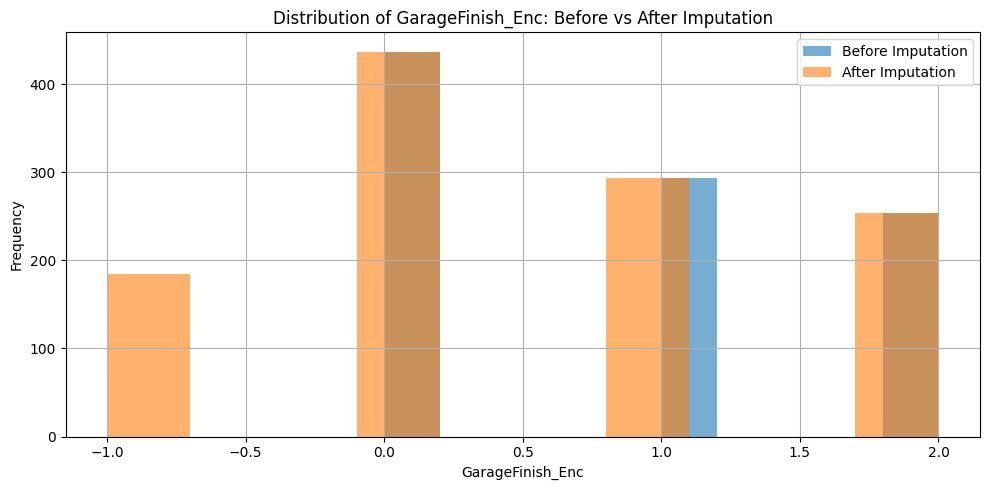

In [ ]:
# Step 1: Create a temporary copy of TrainSet
TrainSet_temp = TrainSet.copy()

# Step 2: Apply imputation using -1 (unknown finish)
TrainSet_temp['GarageFinish_Enc'] = TrainSet_temp['GarageFinish_Enc'].fillna(-1)

# Step 3: Compare distributions
compare_distributions(
    original_series=TrainSet['GarageFinish_Enc'],
    imputed_series=TrainSet_temp['GarageFinish_Enc'],
    variable_name='GarageFinish_Enc'
)


#### Apply Imputation: GarageFinish_Enc

- The distribution comparison confirmed that imputing missing values with `-1` is appropriate.
- This value represents "Unknown finish" and allows the model to distinguish it from known categories without introducing bias.
- We now apply this imputation to both `TrainSet` and `TestSet`.


In [28]:
# Apply final imputation for GarageFinish_Enc
TrainSet['GarageFinish_Enc'] = TrainSet['GarageFinish_Enc'].fillna(-1)
TestSet['GarageFinish_Enc'] = TestSet['GarageFinish_Enc'].fillna(-1)

# Check for missing data
EvaluateMissingData(TrainSet)


['BsmtFinType1_Enc']

### Imputation: BsmtExposure_Enc

- This variable represents the ordinal encoding of basement exposure levels:
  - No exposure: 0
  - Mn: 1
  - Av: 2
  - Gd: 3
- The correlation with `SalePrice` is moderately important.
- Missing values do not necessarily indicate the presence or absence of a basement.
- They simply indicate that **no information was recorded about exposure**, regardless of whether a basement exists.
- Since this feature is ordinal and has predictive value, we will retain it and:
  - Impute missing values with **`-1`**, representing "Unknown exposure".
- This keeps the variable numerically valid while clearly flagging missing information.


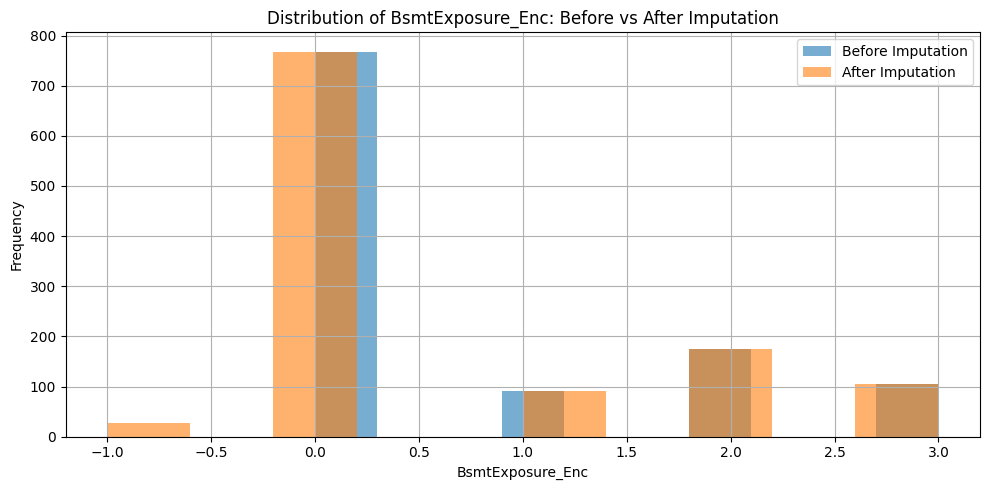

In [45]:
# Step 1: Create a temporary copy of TrainSet
TrainSet_temp = TrainSet.copy()

# Step 2: Apply imputation using -1 to indicate "Unknown exposure"
TrainSet_temp['BsmtExposure_Enc'] = TrainSet_temp['BsmtExposure_Enc'].fillna(-1)

# Step 3: Compare distributions
compare_distributions(
    original_series=TrainSet['BsmtExposure_Enc'],
    imputed_series=TrainSet_temp['BsmtExposure_Enc'],
    variable_name='BsmtExposure_Enc'
)


### Apply Imputation: BsmtExposure_Enc

- The comparison confirmed that using `-1` to represent "Unknown exposure" preserves the ordinal structure without distorting the distribution.
- We now apply this imputation to both `TrainSet` and `TestSet`.


In [29]:
# Apply final imputation for BsmtExposure_Enc
TrainSet['BsmtExposure_Enc'] = TrainSet['BsmtExposure_Enc'].fillna(-1)
TestSet['BsmtExposure_Enc'] = TestSet['BsmtExposure_Enc'].fillna(-1)

# Check for missing data
EvaluateMissingData(TrainSet)


['BsmtFinType1_Enc']

### Imputation: BsmtFinType1_Enc

- This variable is the ordinal encoding of the primary basement finished type.
  - The original categories included options such as:
  - GLQ (Good Living Quarters), ALQ (Average), BLQ (Below Average), Rec (Recreational), LwQ (Low Quality), Unf (Unfinished), and None (No Basement).
- The encoded values reflect an ordinal relationship from low to high finish quality.
- The correlation with `SalePrice` has not yet been checked — we will compute it now to determine importance.
- The correlation with `SalePrice` indicates a moderate relationship.
- Missing values may mean that the information was not recorded — not necessarily that a basement does not exist.
- We will impute missing values with **`-1`** to represent "Unknown".


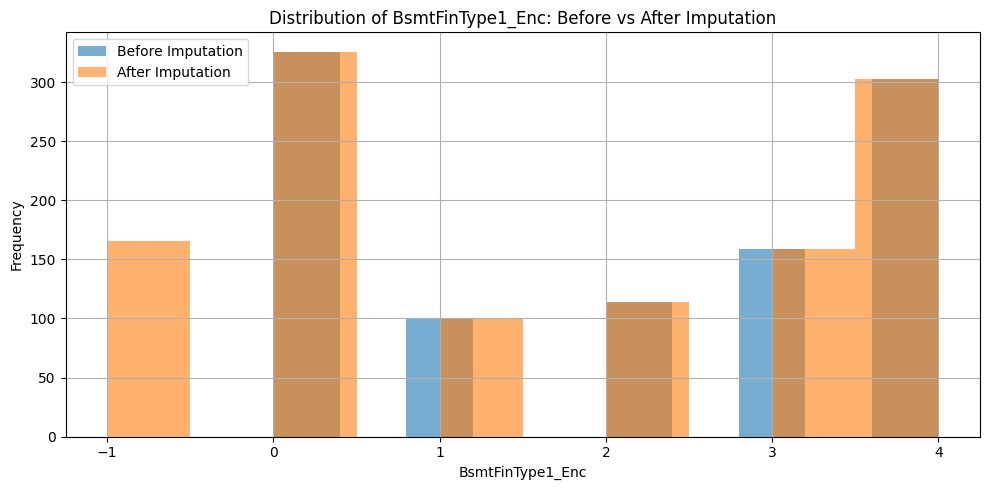

In [30]:
# Step 1: Create a temporary copy of TrainSet
TrainSet_temp = TrainSet.copy()

# Step 2: Apply imputation using -1 to indicate "Unknown finish type"
TrainSet_temp['BsmtFinType1_Enc'] = TrainSet_temp['BsmtFinType1_Enc'].fillna(-1)

# Step 3: Compare distributions
compare_distributions(
    original_series=TrainSet['BsmtFinType1_Enc'],
    imputed_series=TrainSet_temp['BsmtFinType1_Enc'],
    variable_name='BsmtFinType1_Enc'
)


### Apply Imputation: BsmtFinType1_Enc

- The distribution comparison confirms that imputing with `-1` preserves the integrity of the feature.
- We now apply the imputation to both `TrainSet` and `TestSet`, using `-1` to represent "Unknown finish type".


In [32]:
# Apply final imputation for BsmtFinType1_Enc
TrainSet['BsmtFinType1_Enc'] = TrainSet['BsmtFinType1_Enc'].fillna(-1)
TestSet['BsmtFinType1_Enc'] = TestSet['BsmtFinType1_Enc'].fillna(-1)

# Check for missing data
EvaluateMissingData(TrainSet)


[]

---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as they support your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* If you do not need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)
